<div style="text-align: center; margin-top: 80px;">

# **Universidad Internacional de la Rioja (UNIR)**

## Escuela Superior de Ingeniería y Tecnología
## Máster en Computación Cuántica

## Prácticas de empresa
# **[Título]**


### Presentada por: Jon Zapata Muñoz

#### Fecha: Agosto de 2026  

---

</div>

## **Introducción**
El objetivo de este Notebook es crear una aplicación que genere mapas de ruido bidimensionales, aleatorios pero suaves y similares al ruido Perlin utilizando una técnica quantum-inspired basada en redes tensoriales de tipo PEPS (Projected Entangled Pair States) y una arquitectura entrenable.

El código se compone de una clase denominada GenerativePEPS cuyas funciones miembro implementan dicha aplicación. Estas funciones incluyen:
- __init__: el constructor de la clase. Recibe los parámetros necesarios para generar la red tensorial.
- __ContractPEPS__: Aplica las contracciones a la red tensorial para generar el mapa de ruido. Aún está en proceso.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [22]:
class GenerativePEPS(nn.Module):
    def __init__(self, N, D, p, use_torch = False, rng = None):
        """
        Constructor de la clase. Dados una serie de parámetros, genera
        la red tensorial inicial y guarda dichos parámetros para poder generar 
        el mapa de ruido correctamente
        N: La dimensión en píxeles de la imagen resultante
        D: la dimensión de lazo entre los tensores que componen la red tensorial. En esencia, esto representa cuántos
        valores puede tener cada índice. Esto ayuda a generar más suavidad, dando más correlación entre los tensores.
        p: la dimensión física
        use_torch: [temporal] variable para dictaminar si usamos numpy o torch
        rng: un generador de números aleatorios para generar la red tensorial inicial.
        """
        super().__init__()
        self.N = N;
        self.D = D;
        self.p = p;
        self.use_torch = use_torch;
        self.readout = nn.Parameter(torch.randn(D) * 0.1)

        if rng is None:
            rng = np.random.default_rng()
        if(use_torch == True):
            self.tensors = nn.Parameter(torch.rand(N, N, D, D, D, D, p) * 0.1) 
        else: 
            self.tensors = rng.standard_normal((N, N, D, D, D, D, p)) * 0.1
        
        print(f"params per tensor: {D**4 * p}")
        print(f"total params:      {N * N * D**4 * p}")
        
    def forward(self):
        """
        El algoritmo principal de la clase. Genera el mapa de ruido utilizando una red
        tensorial PEPS
        """
        boundary = [torch.ones(self.D, device=self.tensors.device) / self.D for _ in range(self.N)]
        
        noise_map_rows = []

        for row in range(self.N):
            left_vec = torch.zeros(self.D, device=self.tensors.device)
            left_vec[0] = 1.0
            
            current_row_scalars = []
            next_boundary = []

            for col in range(self.N):
                T = self.tensors[row, col]  # Shape: (D, D, D, D, p)
                up_vec = boundary[col]      # Shape: (D,)
                out = torch.einsum('lrudp,l,u->rdp', T, left_vec, up_vec)    # (D, D, p)
                out = out[..., 0]                                             # (D, D)
                
                # Aparentemente se recomeinda hacer un "Learned readout", una
                #ombinacion con pesos entre r y d y ese será el valor de nuestro pixel
                pixel = torch.einsum('rd,r->d', out, self.readout)[0]
                current_row_scalars.append(pixel)

                #utilizamos el readout para evitar hardcodear y leer siempre el indice 0 de nuestros vectores
                #y permitiendo asi que la red aprenda que combinacion de valores de D realmente corresponde
                # a lo que queremos. Nos pregutnamos, basicamente, "de todos los D, como los combino para obtener un numero?"
                right_vec = out @ self.readout                                # (D,)
                down_vec  = self.readout @ out
                
                #right_vec = torch.einsum('lrud,l,u->r', T[...,0,0], left_vec, up_vec)
                # separately get down vector by contracting l, u with d
                #down_vec  = torch.einsum('lrud,l,u->d', T[...,0,0], left_vec, up_vec)
                # Contract bonds safely
                #out_rd = torch.einsum('lrud...,l,u->rd...', T, left_vec, up_vec)
                #out_rd = out_rd.squeeze(-1) # Shape: (D, D)

                #current_row_scalars.append(torch.dot(self.readout, right_vec))
                #current_row_scalars.append(right_vec[0, 0])
                # Out-of-place: Collect the scalar into a list
                #current_row_scalars.append(out_rd[0, 0])

                # Get downstream vectors
                #new_right = torch.sum(out_rd, dim=1)
                #new_down = torch.sum(out_rd, dim=0)

                left_vec = right_vec / (torch.norm(right_vec) + 1e-8)
                normalized_down = down_vec / (torch.norm(down_vec) + 1e-8)
                # Normalize (Creates fresh, new tensors out-of-place)
                #left_vec = new_right / (torch.norm(new_right) + 1e-8)
                #normalized_down = new_down / (torch.norm(new_down) + 1e-8)
                
                # Queue the updated boundary vector for the NEXT row
                next_boundary.append(normalized_down)

            # Move to the next row: swap the boundary reference completely
            boundary = next_boundary
            
            # Stack this row's list of scalars into a 1D tensor
            noise_map_rows.append(torch.stack(current_row_scalars))

        # Stack all row tensors into the final 2D noise map
        noise_map = torch.stack(noise_map_rows)
        return noise_map
        
    def CreateTargetPowerSpectrum(self, N, alpha=2.0):
        k_x = torch.fft.fftfreq(N)
        k_y = torch.fft.fftfreq(N)
        K_x, K_y = torch.meshgrid(k_x, k_y, indexing='ij')
        
        k_mag = torch.sqrt(K_x**2 + K_y**2)
        
        # Build target with DC explicitly excluded from the start
        target = torch.zeros(N, N)
        nonzero = k_mag > 1e-8
        target[nonzero] = 1.0 / (k_mag[nonzero] ** alpha)
        
        # Normalize only over non-DC bins
        return target / (target.sum() + 1e-8)
    
    def ComputeSpectralLoss(self, generated_map, target_spectrum):
        """ Mide el error medio (al cuadrado) entre las frecuencias generadas y objetivo."""
        # Parece que es importante centrar el mapa en 0 para centrarse solo en los patrones de la textura
        shifted_map = generated_map - generated_map.mean()
        
        # 2D Fast Fourier Transform para extraer las frecuencias
        fft_coeffs = torch.fft.fft2(shifted_map)
        generated_spectrum = torch.abs(fft_coeffs) ** 2
        
        # Normalizar para comparar
        generated_spectrum = generated_spectrum / (generated_spectrum.sum() + 1e-8)

        return torch.mean((generated_spectrum - target_spectrum) ** 2)
        
    def ContractPEPSNumpy(self):
        """
        El algoritmo principal de la clase. Genera el mapa de ruido utilizando una red
        tensorial PEPS
        """
        noise_map = np.zeros((self.N, self.N))
    
        # Inicializamos la frontera superior: un vector de D dimensiones por columna
        boundary = np.ones((self.N, self.D)) / self.D

        
        for row in range(N):
            #por cada fila, una nueva frontera a la izquierda vacía
            left_vec = np.zeros(self.D)
            left_vec[0] = 1.0
    
            for col in range(N):
                T = self.tensors[row, col]        # Shape: (D, D, D, D, p)
                up_vec = boundary[col]       # Shape: (D,)
    
                # Contraemos los vectores de arriba y de la izquierda de forma simultánea.
                # l: left, r: right, u: up, d: down
                # El resultado será una matriz de dimensiones (r, d) que contiene los vectores right y down (sin normalizar) 
                # emparejados.
                out_rd = np.einsum('lrud,l,u->rd', T[..., 0], left_vec, up_vec)
                
                # RGuardamos el valor del mapa (e.g., r=0, d=0)
                noise_map[row, col] = out_rd[0, 0]
    
                # Desparejamos el resutlado (r, d) , moviéndolos a vectores right y down separados.
                # De momento, lo hacemos así.
                new_right = np.sum(out_rd, axis=1) # Sum out 'd' to get 'r'
                new_down = np.sum(out_rd, axis=0)  # Sum out 'r' to get 'd'
    
                # Normalizamos y pasamos al siguiente vector
                left_vec = new_right / (np.linalg.norm(new_right) + 1e-10)
                boundary[col] = new_down / (np.linalg.norm(new_down) + 1e-10)
    
        return noise_map

params per tensor: 4096
total params:      1638400


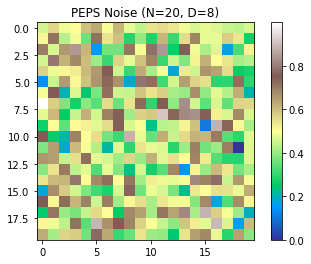

In [23]:
N = 20
D = 8
p = 1
rng = np.random.default_rng(36)
peps = GenerativePEPS(N, D, p, False, rng)

# Now uses the inferred N and D safely
raw_map = peps.ContractPEPSNumpy()

display_map = (raw_map - raw_map.min()) / (raw_map.max() - raw_map.min() + 1e-10)
plt.imshow(display_map, cmap='terrain')
plt.colorbar()
plt.title(f"PEPS Noise (N={N}, D={D})")
plt.show()

params per tensor: 256
total params:      36864
  grad magnitudes: min=1.85e-06 max=4.77e-03
Epoch   0 | spec=0.000209 | tv=0.082114 | var=-0.002510 | std=0.0501 | range=0.1402
  grad magnitudes: min=1.78e-06 max=4.67e-03
  grad magnitudes: min=1.71e-06 max=4.62e-03
  grad magnitudes: min=1.59e-06 max=4.43e-03
  grad magnitudes: min=1.58e-06 max=4.31e-03
Epoch  25 | spec=0.000177 | tv=0.015985 | var=-0.000057 | std=0.0075 | range=0.0410
Epoch  50 | spec=0.000129 | tv=0.022308 | var=-0.000136 | std=0.0117 | range=0.0734
Epoch  75 | spec=0.000186 | tv=0.028356 | var=-0.000179 | std=0.0134 | range=0.0831
Epoch 100 | spec=0.000177 | tv=0.035423 | var=-0.000276 | std=0.0166 | range=0.0837
Epoch 125 | spec=0.000153 | tv=0.034715 | var=-0.000362 | std=0.0190 | range=0.0951
Epoch 150 | spec=0.000158 | tv=0.037517 | var=-0.000417 | std=0.0204 | range=0.1134
Epoch 175 | spec=0.000213 | tv=0.041186 | var=-0.000406 | std=0.0201 | range=0.0991
Epoch 200 | spec=0.000141 | tv=0.039629 | var=-0.000471

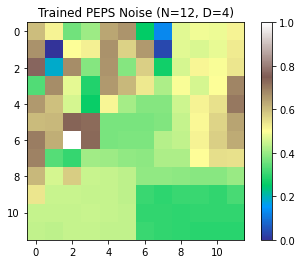

In [28]:
N = 12
D = 4
p = 1
alpha = 2.0
lr = 0.005
lambda_tv = 0.02  
lambda_var = 0.03

model = GenerativePEPS(N, D, p, True, rng)
optimizer = optim.Adam(model.parameters(), lr=lr)
target_spectrum = model.CreateTargetPowerSpectrum(N, alpha)
# --- Loop de entrenamiento ---
epochs = 300
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Generar el mapa de ruido
    generated_map = model()
    spectral_loss = model.ComputeSpectralLoss(generated_map, target_spectrum)
    # 1. Total Variation Loss
    # Penaliza diferencias entre píxeles adyacentes
    diff_h = torch.abs(generated_map[:, 1:] - generated_map[:, :-1]).mean()
    diff_v = torch.abs(generated_map[1:, :] - generated_map[:-1, :]).mean()
    tv_loss = diff_h + diff_v
    
    # Variance Loss (Evita que el mapa sea completamente plano o gris)
    var_loss = -torch.var(generated_map) 
    
    # Total loss: equilibra suavidad y contraste
    total_loss = spectral_loss + (lambda_tv * tv_loss) + (lambda_var * var_loss)
    
    total_loss.backward()
    if epoch < 5:
        grads = [p.grad.abs().mean().item() 
                 for p in model.parameters() 
                 if p.grad is not None]
        print(f"  grad magnitudes: min={min(grads):.2e} max={max(grads):.2e}")

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    if epoch % 25 == 0:
        with torch.no_grad():
            raw_std = generated_map.std().item()
            raw_range = (generated_map.max() - generated_map.min()).item()
        print(f"Epoch {epoch:3d} | "
              f"spec={spectral_loss.item():.6f} | "
              f"tv={tv_loss.item():.6f} | "
              f"var={var_loss.item():.6f} | "
              f"std={raw_std:.4f} | "
              f"range={raw_range:.4f}")

# --- Visualization ---
with torch.no_grad():
    final_map = model()
    # Normalize for display
    display_map = (final_map - final_map.min()) / (final_map.max() - final_map.min())

plt.imshow(display_map.numpy(), cmap='terrain')
plt.colorbar()
plt.title(f"Trained PEPS Noise (N={N}, D={D})")
plt.show()

#guardar mapas de diferentes épocas.
# buscar métricas estandarizadas para medir la suavidad. 